# SECTION 1 — ENVIRONMENT SETUPInstall and import all required libraries, set random seeds for reproducibility, and suppress warnings.

In [2]:
# ============================================================
# SECTION 1 — ENVIRONMENT SETUP
# Install / import libraries, set seeds, suppress warnings
# ============================================================

# --- Install dependencies (uncomment if running for the first time) ---
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow deap pyarrow -q

# --- Standard library imports ---
import os
import time
import json
import random
import warnings

# --- Suppress warnings ---
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # suppress TF info/warning logs

# --- Third-party imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from deap import base, creator, tools, algorithms

# --- Reproducibility seeds ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --- Plot style ---
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("\u2705 Environment setup complete. All libraries imported and seeds set to", SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 5.8 MB/s eta 0:00:00
✅ Environment setup complete. All libraries imported and seeds set to 42


# SECTION 2 — DATA LOADINGLoad the UNSW-NB15 training and testing datasets. Supports both `.parquet` and `.csv` formats — whichever is present in the working directory. Print shapes, dtypes, head, and missing-value counts.

In [3]:
# ============================================================
# SECTION 2 — DATA LOADING
# Load training and testing datasets (parquet or csv)
# ============================================================

def load_dataset(base_name):
    """
    Load a dataset by base_name, trying .parquet first then .csv.
    Returns a pandas DataFrame.
    """
    parquet_path = f"{base_name}.parquet"
    csv_path     = f"{base_name}.csv"
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
        print(f"\u2705 Loaded from '{parquet_path}'")
        return df
    elif os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f"\u2705 Loaded from '{csv_path}'")
        return df
    else:
        raise FileNotFoundError(
            f"Neither '{parquet_path}' nor '{csv_path}' found. "
            "Place the data file in the notebook directory."
        )

TRAIN_BASE = "UNSW_NB15_training-set"
TEST_BASE  = "UNSW_NB15_testing-set"

df_train = load_dataset(TRAIN_BASE)
df_test  = load_dataset(TEST_BASE)

# --- Shapes ---
print(f"\nTraining set shape: {df_train.shape}")
print(f"Testing  set shape: {df_test.shape}")

# --- Dtypes ---
print("\n--- Training set dtypes ---")
print(df_train.dtypes)

print("\n--- Testing set dtypes ---")
print(df_test.dtypes)

# --- First 5 rows ---
print("\n--- Training set (first 5 rows) ---")
display(df_train.head())

print("\n--- Testing set (first 5 rows) ---")
display(df_test.head())

# --- Missing values ---
print("\n--- Missing values (Training) ---")
print(df_train.isnull().sum())

print("\n--- Missing values (Testing) ---")
print(df_test.isnull().sum())

✅ Loaded from 'UNSW_NB15_training-set.parquet'
✅ Loaded from 'UNSW_NB15_testing-set.parquet'

Training set shape: (175341, 36)
Testing  set shape: (82332, 36)

--- Training set dtypes ---
dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
re

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0



--- Testing set (first 5 rows) ---


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.09375,180363632.0,...,0,0,1,1,0,0,0,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.00000,881000000.0,...,0,0,1,1,0,0,0,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.00000,854400000.0,...,0,0,1,1,0,0,0,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.65625,600000000.0,...,0,0,2,1,0,0,0,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.00000,850400000.0,...,0,0,2,1,0,0,0,0,Normal,0



--- Missing values (Training) ---
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

--- Missing values (Testing) ---
dur                  0
proto                0
service              0
state                

# SECTION 3 — EXPLORATORY DATA ANALYSIS (EDA)Thorough EDA with class distributions, attack category analysis, feature types, statistical summaries, missing-value heatmap, KDE plots, correlation heatmap, outlier boxplots, variance bar chart, and pairplot.

## 3a. Class Distribution

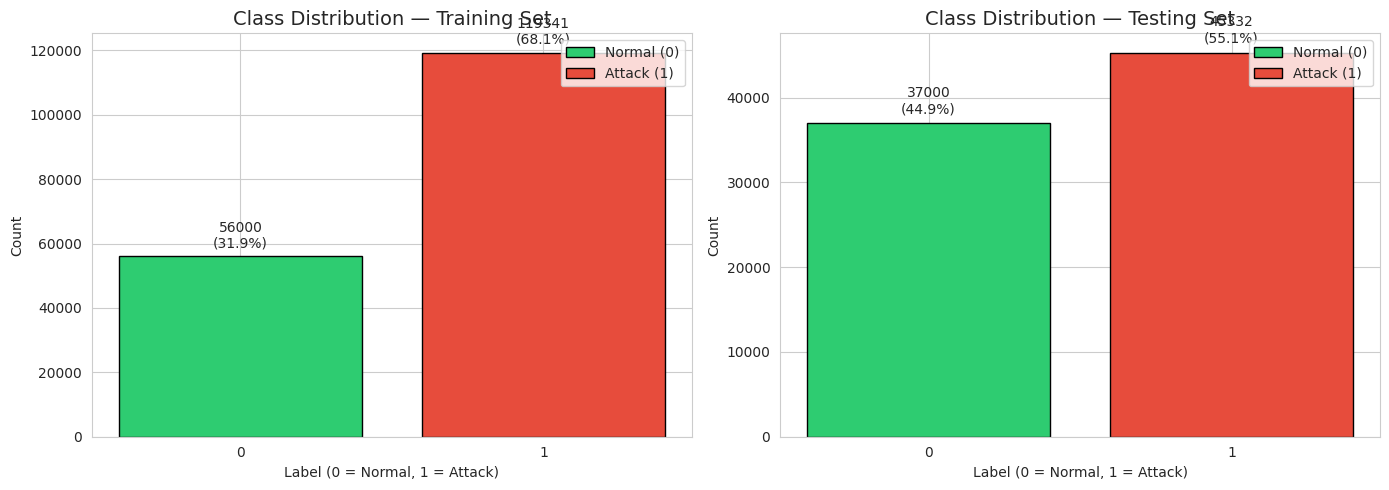


Training set class distribution:
  Label 0: 56,000 (31.94%)
  Label 1: 119,341 (68.06%)

Testing set class distribution:
  Label 0: 37,000 (44.94%)
  Label 1: 45,332 (55.06%)


In [4]:
# ============================================================
# 3a — Class Distribution bar charts for train and test
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes, [df_train, df_test], ["Training Set", "Testing Set"]):
    counts = df["label"].value_counts().sort_index()
    total = counts.sum()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=["#2ecc71", "#e74c3c"], edgecolor="black")
    ax.set_title(f"Class Distribution — {title}", fontsize=14)
    ax.set_xlabel("Label (0 = Normal, 1 = Attack)")
    ax.set_ylabel("Count")
    ax.legend(bars, ["Normal (0)", "Attack (1)"], loc="upper right")
    for bar, cnt in zip(bars, counts.values):
        pct = cnt / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
                f"{cnt}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Print exact counts
for name, df in [("Training", df_train), ("Testing", df_test)]:
    counts = df["label"].value_counts().sort_index()
    total = counts.sum()
    print(f"\n{name} set class distribution:")
    for label, cnt in counts.items():
        print(f"  Label {label}: {cnt:,} ({cnt/total*100:.2f}%)")

## 3b. Attack Category Analysis

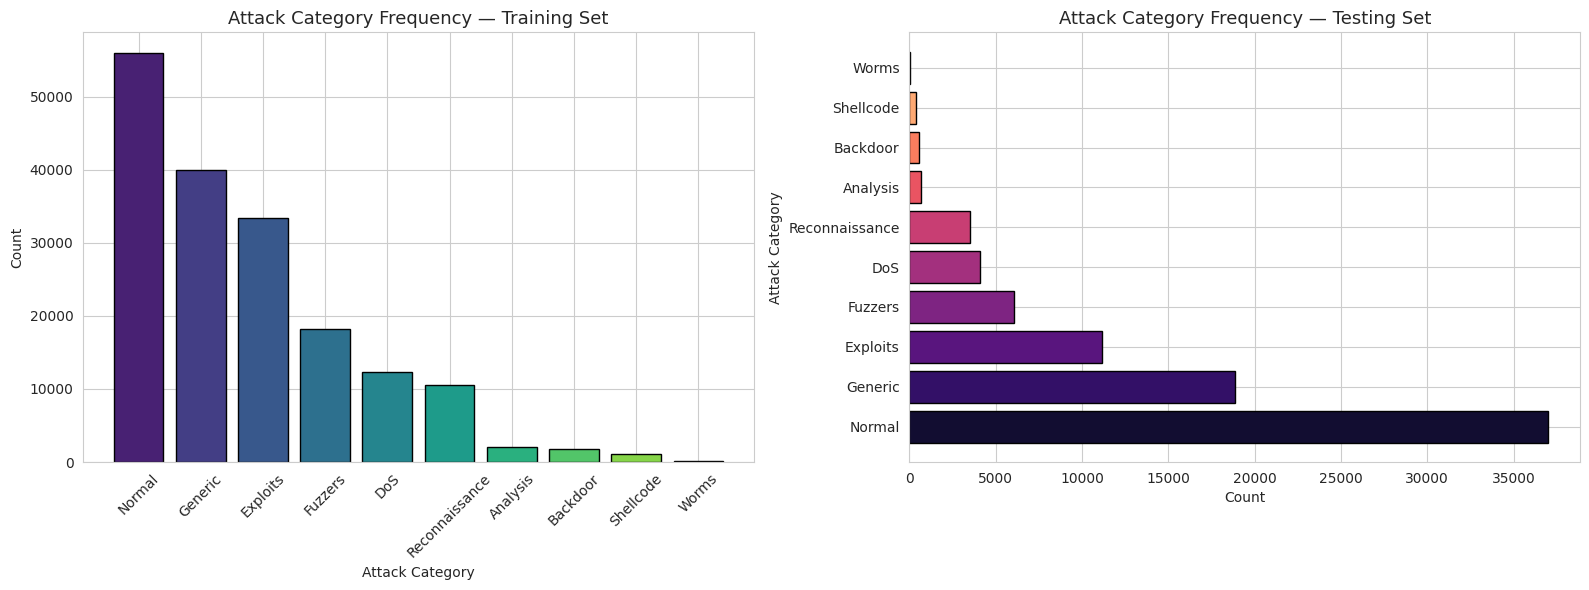

In [5]:
# ============================================================
# 3b — Attack Category frequency charts (before dropping attack_cat)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set — vertical bar chart
cat_counts_train = df_train["attack_cat"].value_counts()
axes[0].bar(cat_counts_train.index.astype(str), cat_counts_train.values,
            color=sns.color_palette("viridis", len(cat_counts_train)), edgecolor="black")
axes[0].set_title("Attack Category Frequency — Training Set", fontsize=13)
axes[0].set_xlabel("Attack Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Testing set — horizontal bar chart
cat_counts_test = df_test["attack_cat"].value_counts()
axes[1].barh(cat_counts_test.index.astype(str), cat_counts_test.values,
             color=sns.color_palette("magma", len(cat_counts_test)), edgecolor="black")
axes[1].set_title("Attack Category Frequency — Testing Set", fontsize=13)
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Attack Category")

plt.tight_layout()
plt.show()

## 3c. Feature Data Types

In [6]:
# ============================================================
# 3c — Count numerical vs categorical features
# ============================================================

# Identify categorical columns (category dtype or object dtype)
categorical_cols = [c for c in df_train.columns
                    if df_train[c].dtype.name == "category" or df_train[c].dtype == object]
numerical_cols = [c for c in df_train.columns if c not in categorical_cols]

print(f"Numerical features : {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

type_summary = pd.DataFrame({
    "Column": df_train.columns,
    "Dtype": [str(df_train[c].dtype) for c in df_train.columns],
    "Type": ["Categorical" if c in categorical_cols else "Numerical" for c in df_train.columns]
})
display(type_summary)

Numerical features : 32
Categorical features: 4


,Column,Dtype,Type
0,dur,float32,Numerical
1,proto,category,Categorical
2,service,category,Categorical
3,state,category,Categorical
4,spkts,int16,Numerical
5,dpkts,int16,Numerical
6,sbytes,int32,Numerical
7,dbytes,int32,Numerical
8,rate,float32,Numerical
9,sload,float32,Numerical


## 3d. Statistical Summary

In [7]:
# ============================================================
# 3d — Descriptive statistics for all numerical features
# ============================================================

num_only = df_train[numerical_cols]
display(num_only.describe().T)

,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.359389e+00,6.483313e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540618e+04,1.654177e+05,0.0,32.786140,3225.806641,1.250000e+05,1.000000e+06
sload,175341.0,7.345403e+07,1.883701e+08,0.0,13053.338867,879674.750000,8.888889e+07,5.988000e+09
dload,175341.0,6.712055e+05,2.423637e+06,0.0,0.000000,1447.022705,2.784487e+04,2.242273e+07
sloss,175341.0,4.953000e+00,6.600506e+01,0.0,0.000000,0.000000,3.000000e+00,4.803000e+03
dloss,175341.0,6.948010e+00,5.273300e+01,0.0,0.000000,0.000000,2.000000e+00,5.484000e+03


## 3e. Missing Values Heatmap

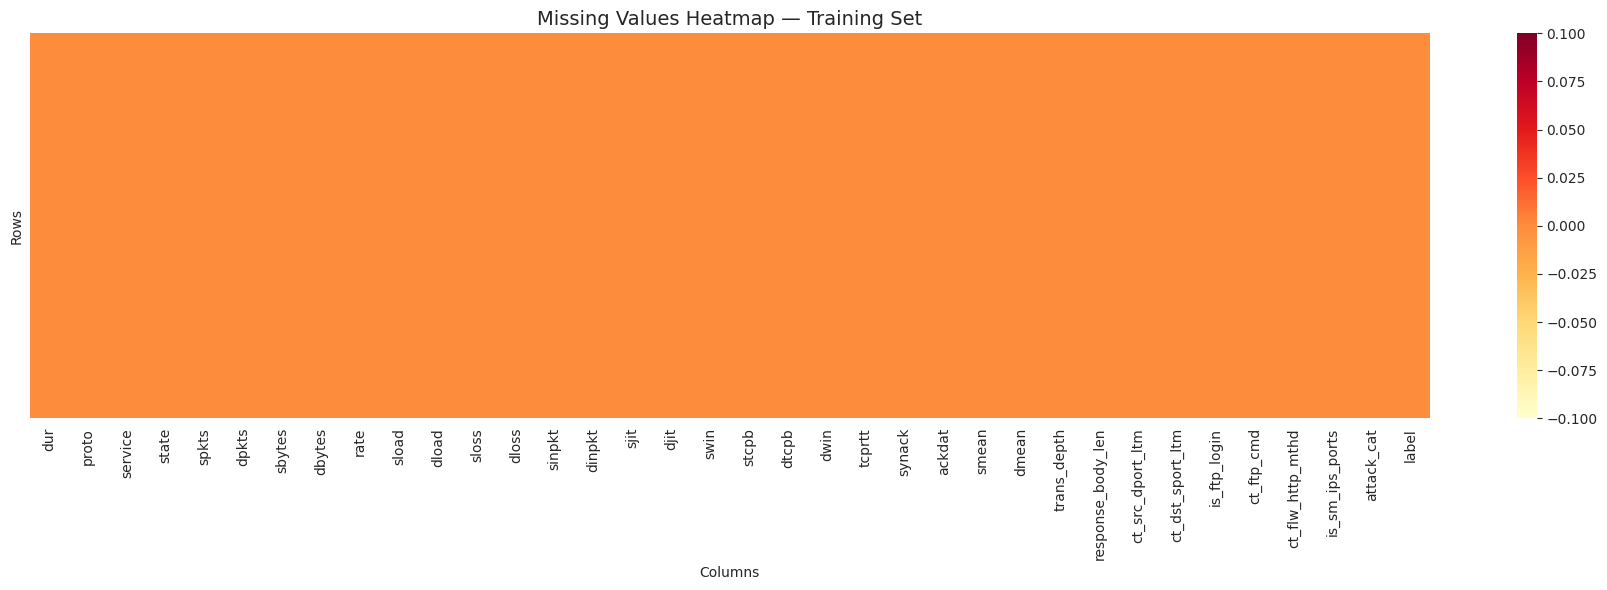

Total missing values in training set: 0


In [8]:
# ============================================================
# 3e — Missing values heatmap for the training set
# ============================================================

plt.figure(figsize=(18, 6))
sns.heatmap(df_train.isnull().astype(int), cbar=True, cmap="YlOrRd", yticklabels=False)
plt.title("Missing Values Heatmap — Training Set", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

total_missing = df_train.isnull().sum().sum()
print(f"Total missing values in training set: {total_missing}")

## 3f. Class-wise Feature Distributions (Top 10 by Variance)

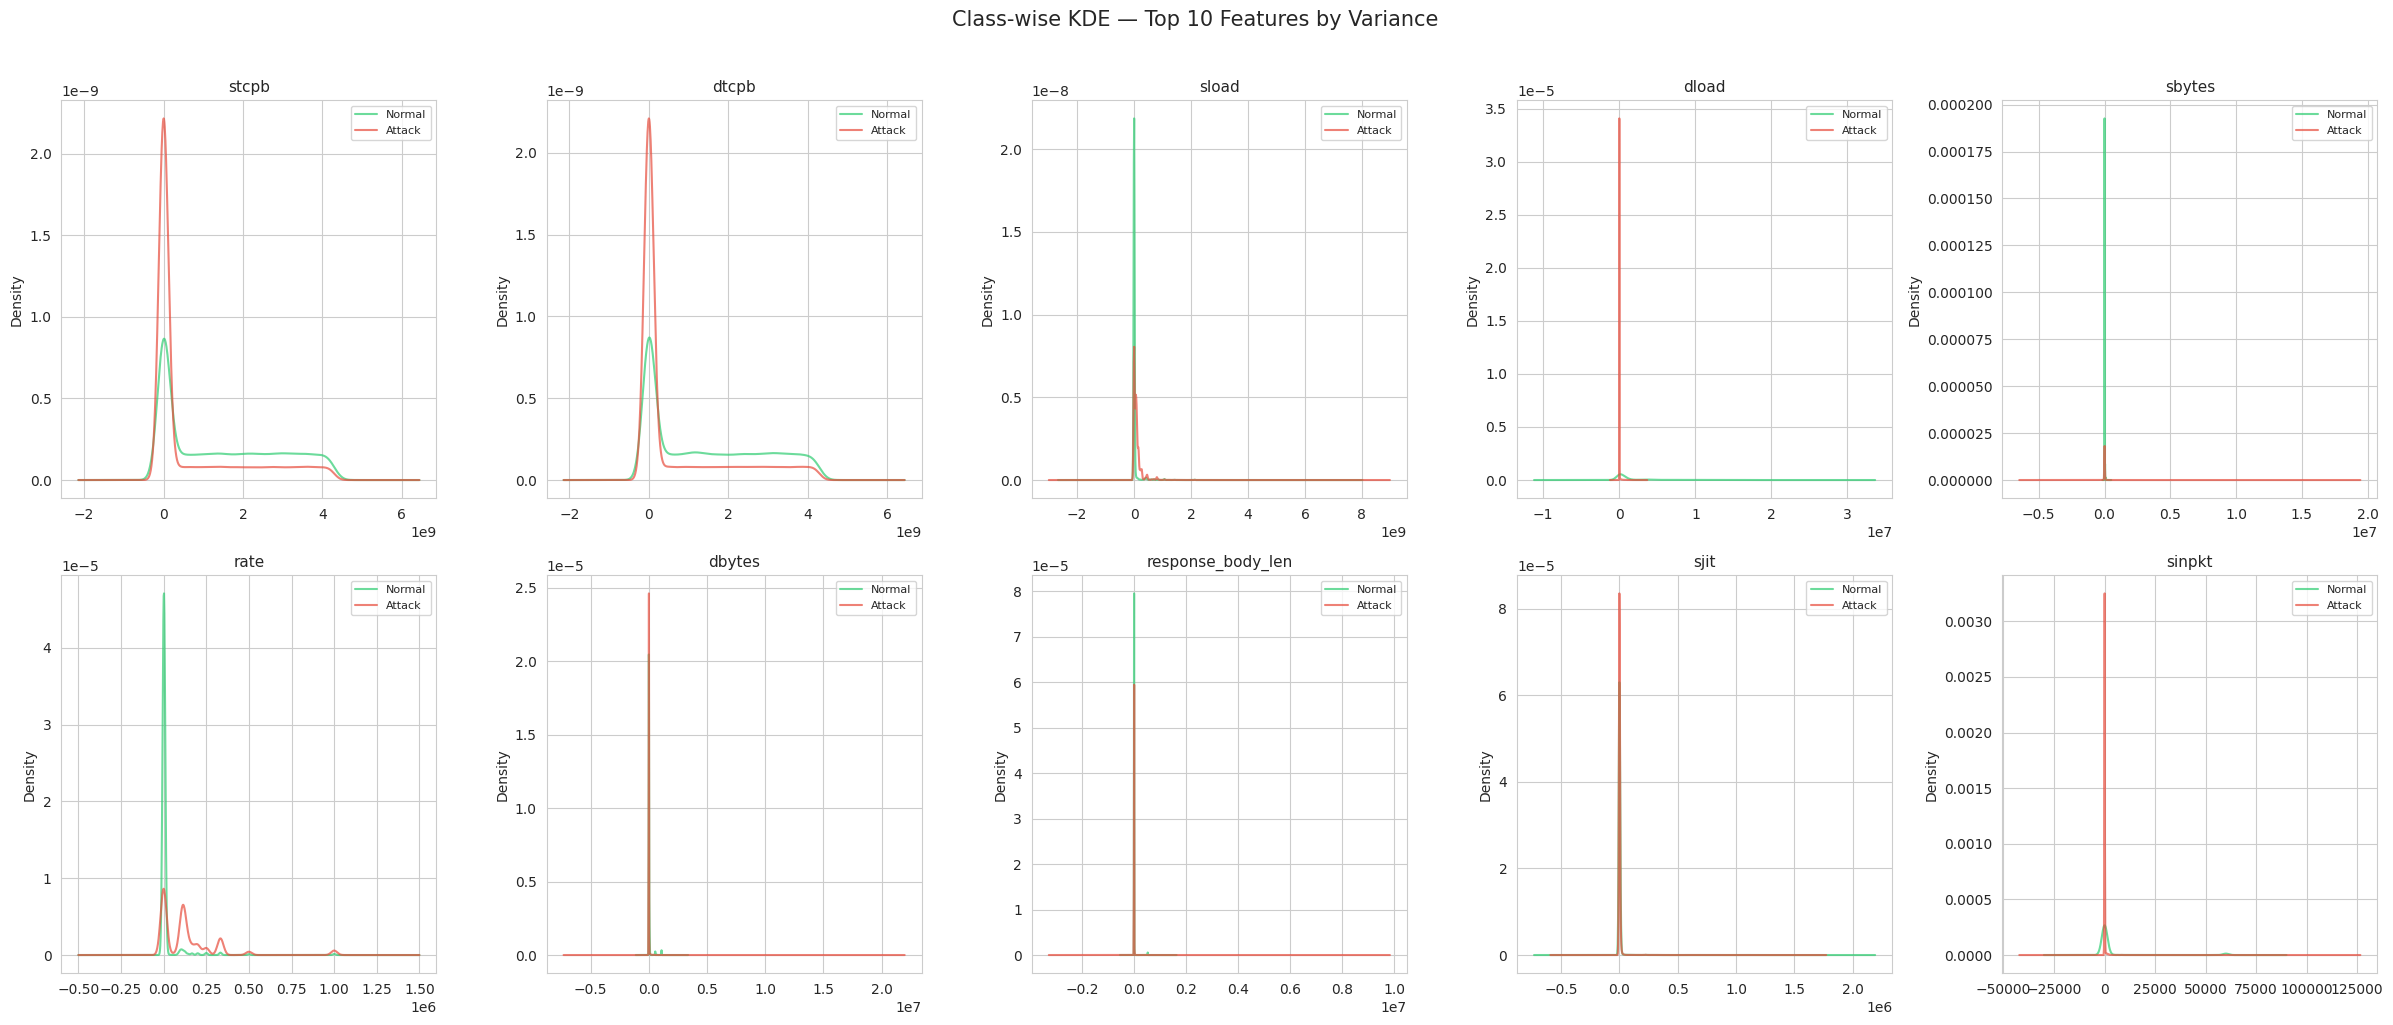

In [9]:
# ============================================================
# 3f — KDE plots for top 10 numerical features by variance,
#       coloured by class label
# ============================================================

# Compute variance for numerical columns (exclude label and categorical)
num_feat_cols = [c for c in numerical_cols if c != "label"]
variances = df_train[num_feat_cols].var().sort_values(ascending=False)
top10_var = variances.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(top10_var):
    for label_val, color, lbl in [(0, "#2ecc71", "Normal"), (1, "#e74c3c", "Attack")]:
        subset = df_train.loc[df_train["label"] == label_val, col].dropna()
        subset.plot.kde(ax=axes[i], color=color, label=lbl, alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)

plt.suptitle("Class-wise KDE — Top 10 Features by Variance", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 3g. Correlation Heatmap

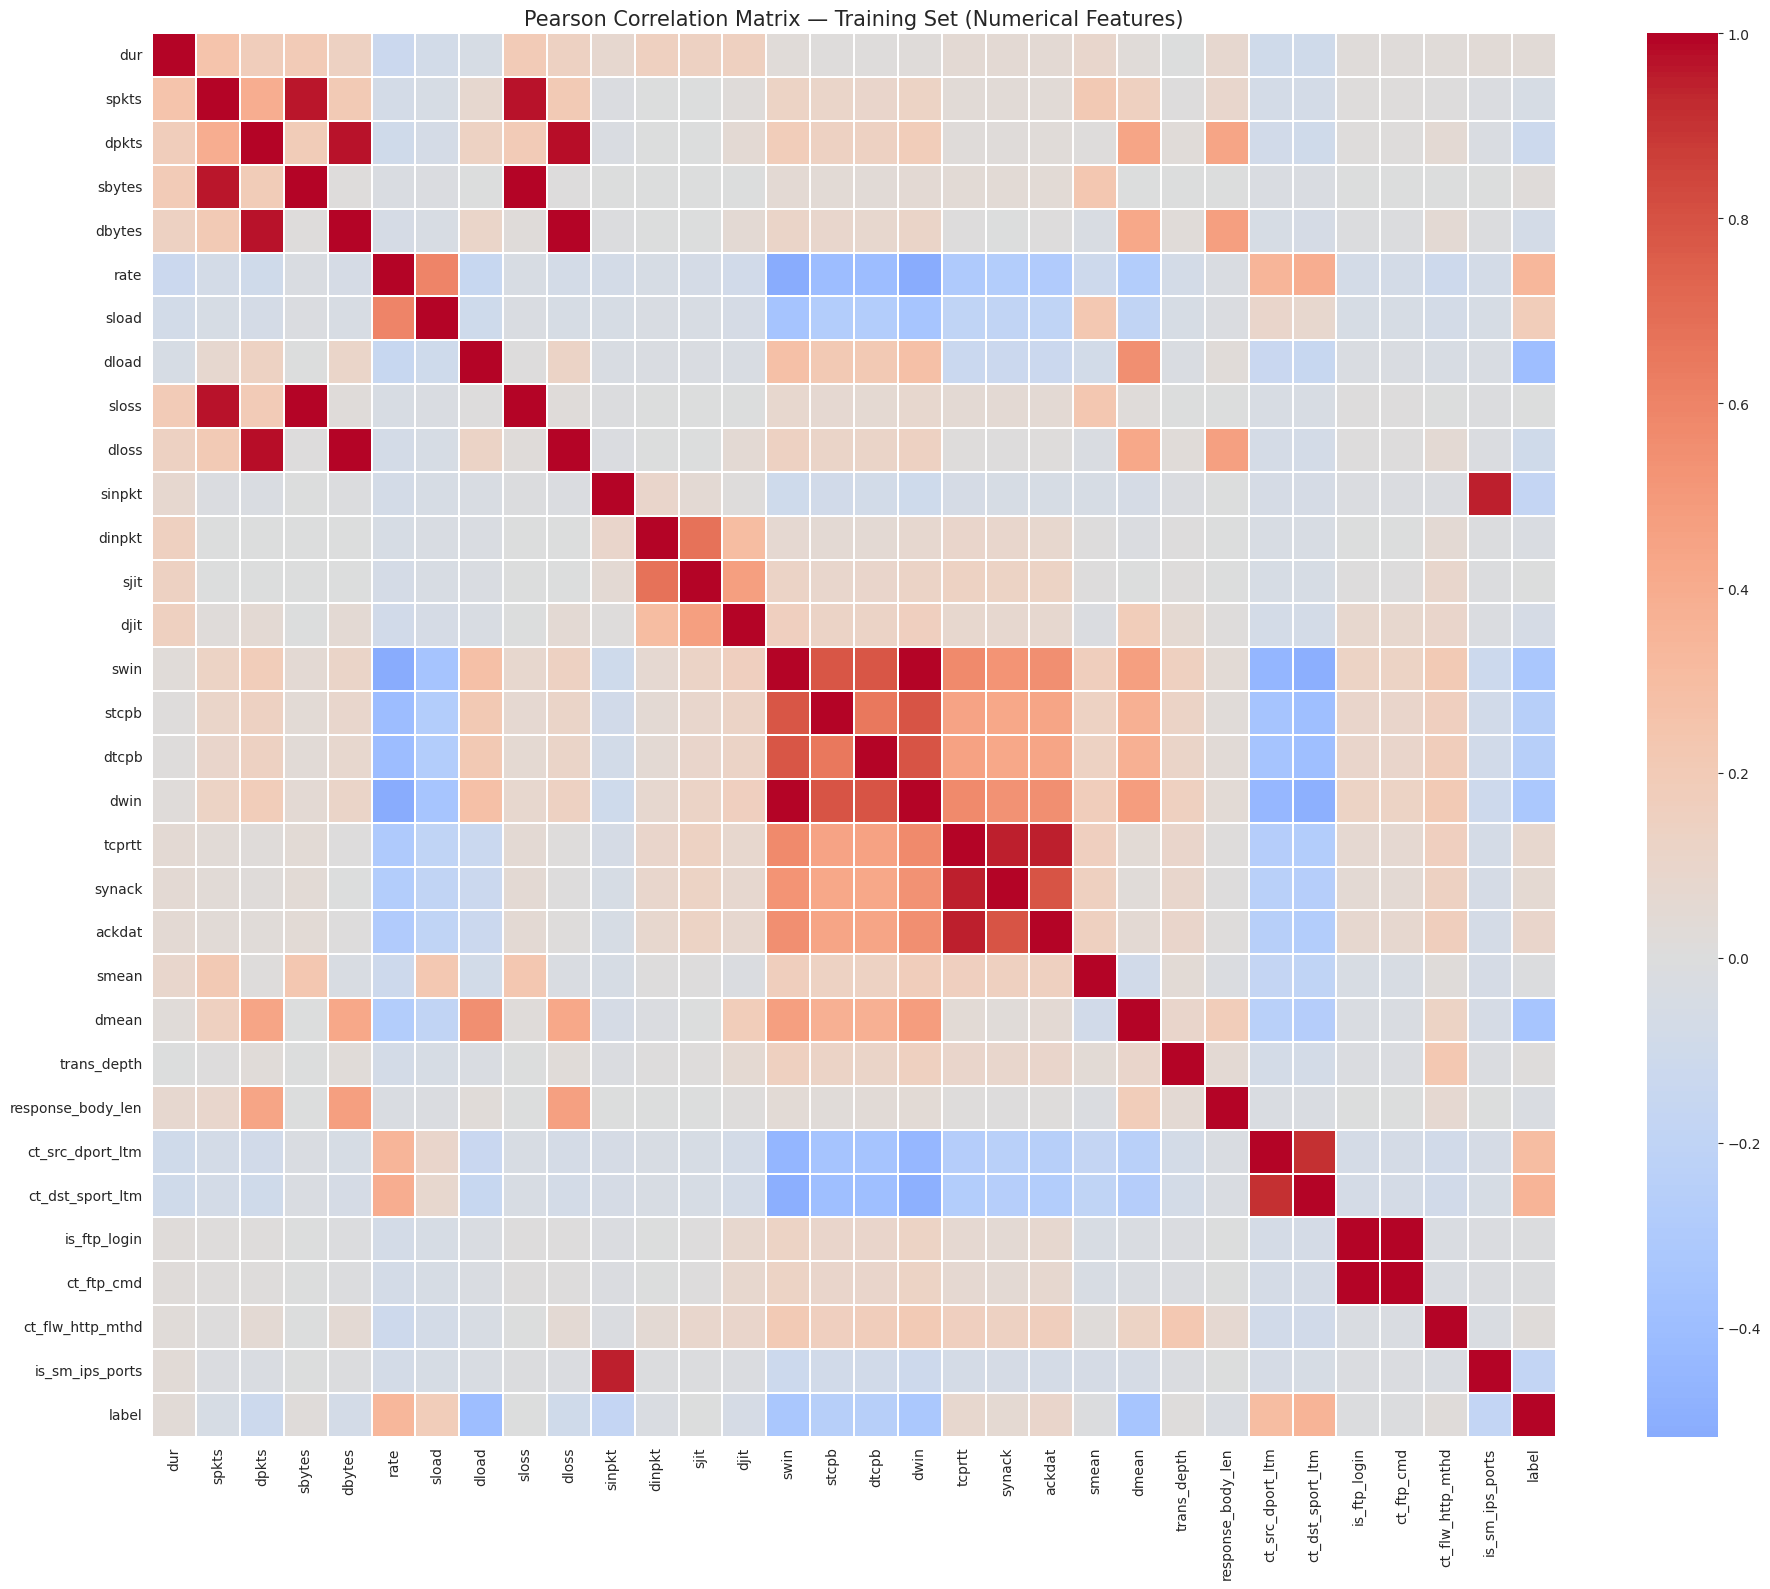


Top 5 features most correlated with label:
  dload: 0.3937
  ct_dst_sport_ltm: 0.3572
  dmean: 0.3418
  rate: 0.3380
  swin: 0.3336


In [10]:
# ============================================================
# 3g — Pearson correlation heatmap for all numerical features
# ============================================================

corr_matrix = df_train[numerical_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.1,
            fmt=".1f", square=True)
plt.title("Pearson Correlation Matrix — Training Set (Numerical Features)", fontsize=15)
plt.tight_layout()
plt.show()

# Top 5 features most correlated with label
if "label" in corr_matrix.columns:
    label_corr = corr_matrix["label"].drop("label").abs().sort_values(ascending=False)
    print("\nTop 5 features most correlated with label:")
    for feat, val in label_corr.head(5).items():
        print(f"  {feat}: {val:.4f}")

## 3h. Outlier Detection (Top 8 Features by Variance)

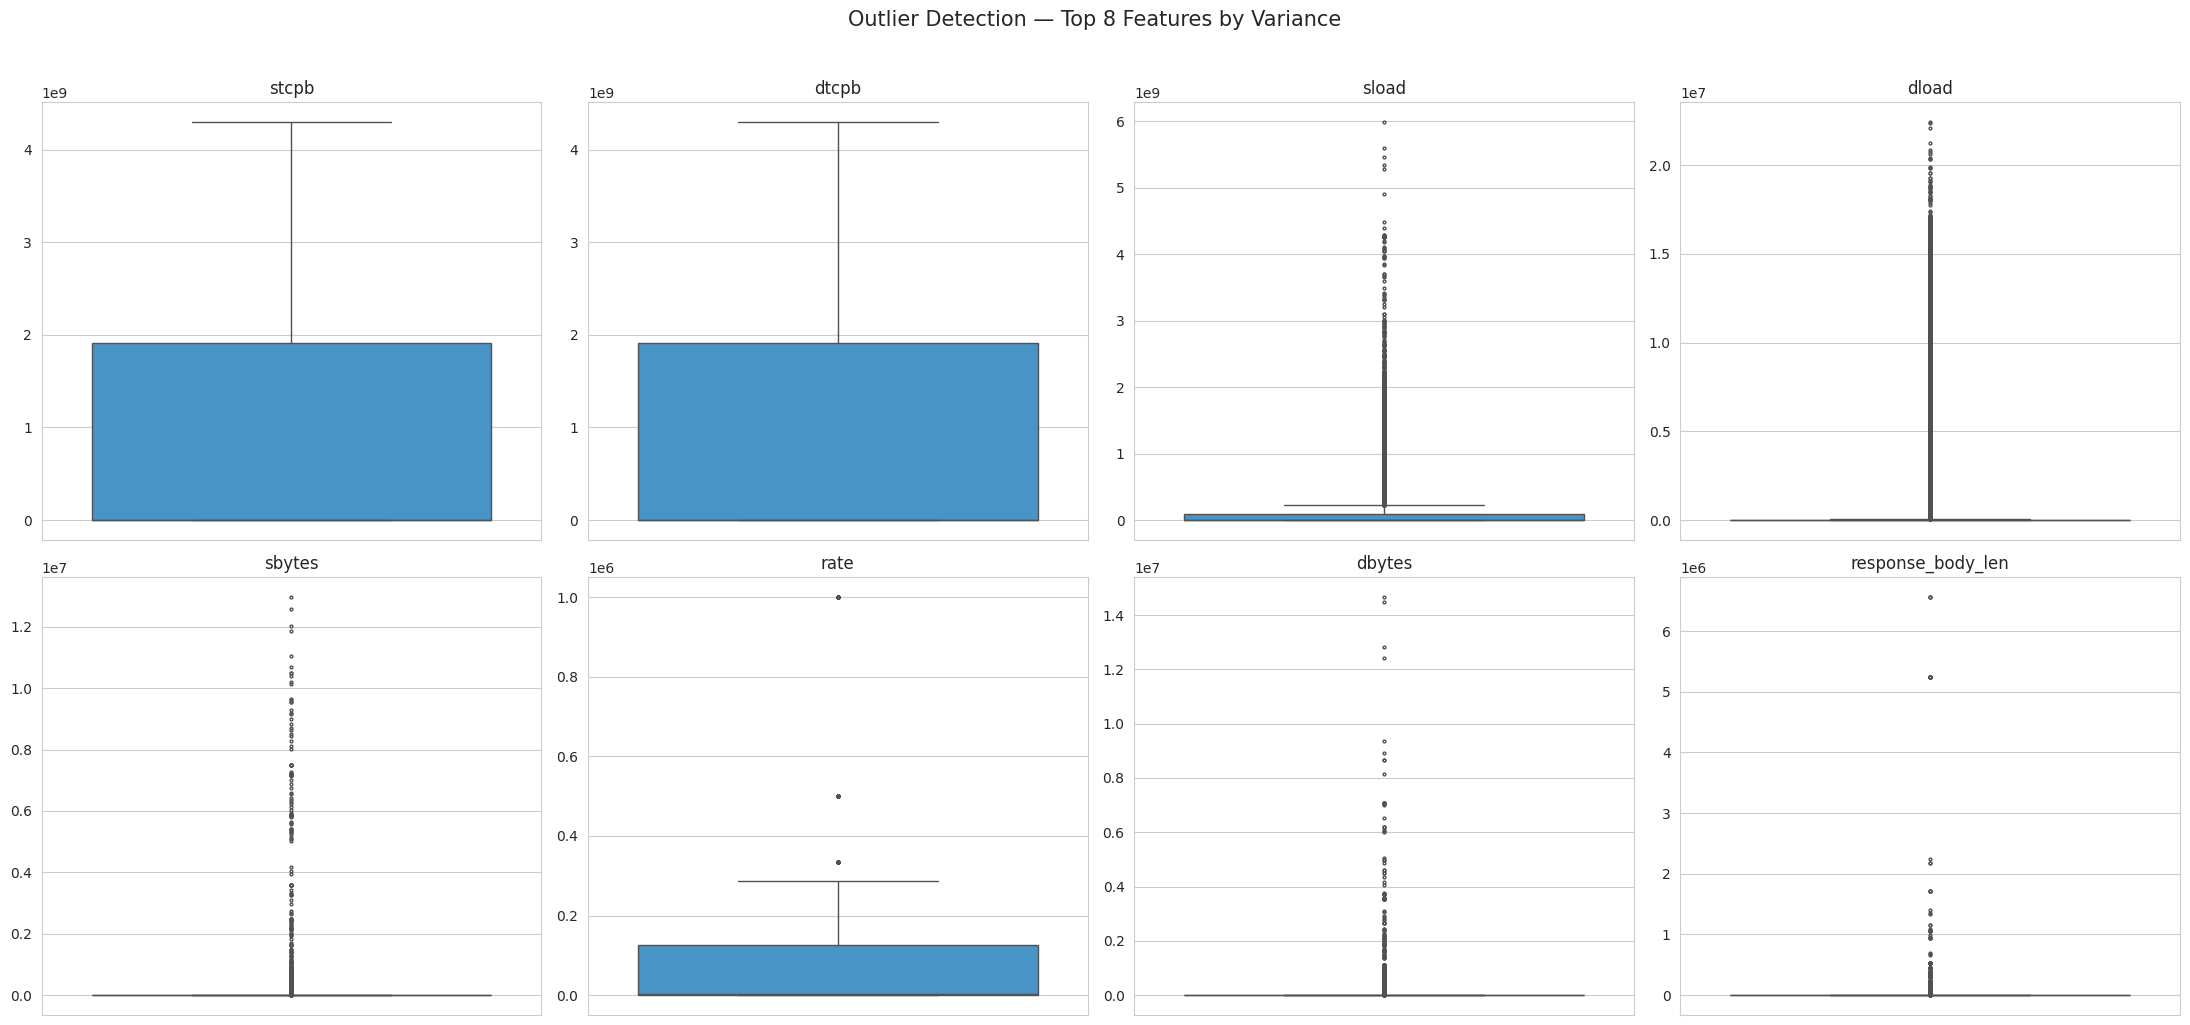

In [11]:
# ============================================================
# 3h — Boxplots for top 8 numerical features by variance
# ============================================================

top8_var = variances.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(top8_var):
    sns.boxplot(data=df_train, y=col, ax=axes[i], color="#3498db", fliersize=2)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("")

plt.suptitle("Outlier Detection — Top 8 Features by Variance", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 3i. Feature Variance Bar Chart

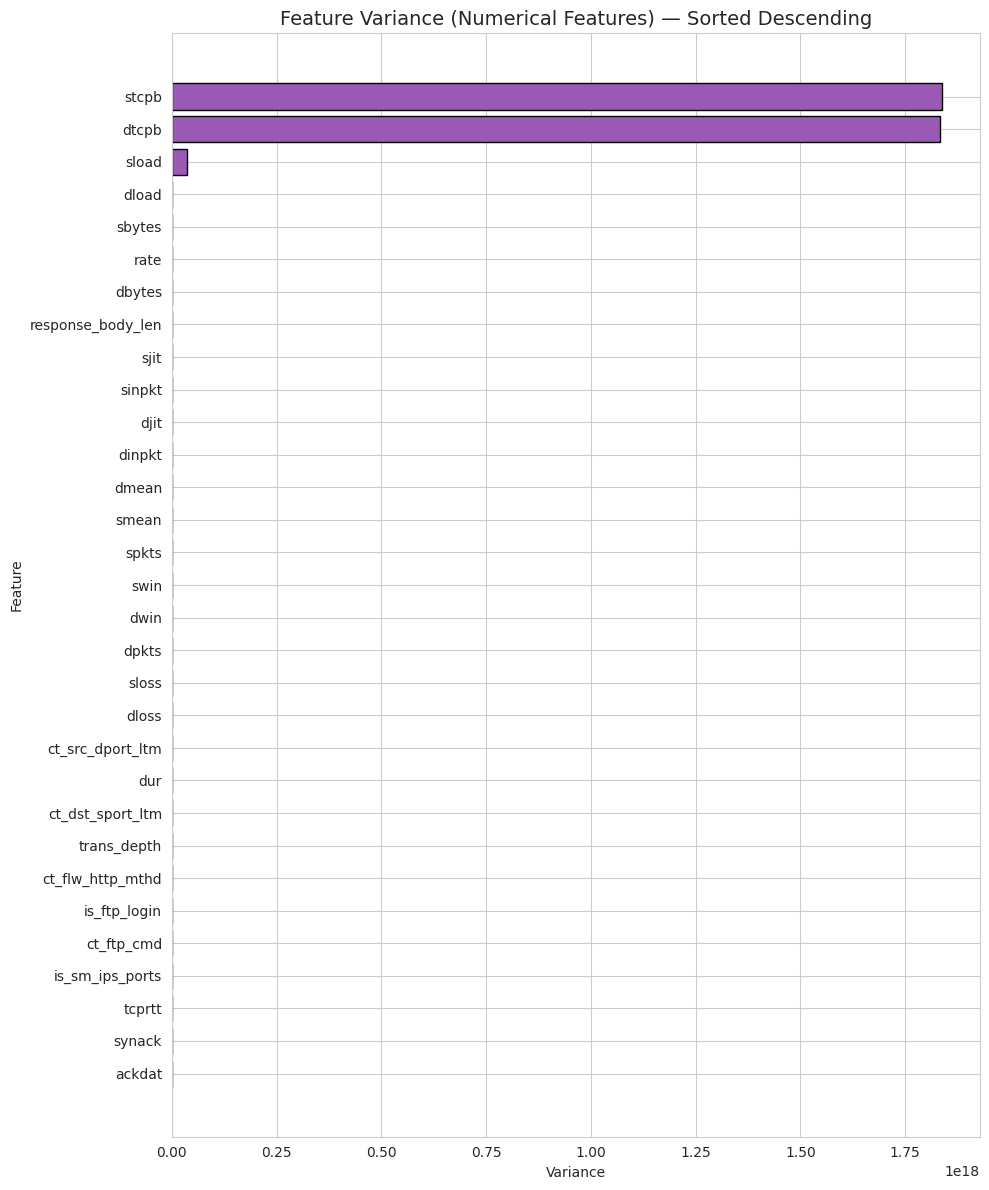

In [12]:
# ============================================================
# 3i — Horizontal bar chart of variance for every numerical feature
# ============================================================

plt.figure(figsize=(10, 12))
var_sorted = variances.sort_values(ascending=True)
plt.barh(var_sorted.index, var_sorted.values, color="#9b59b6", edgecolor="black")
plt.title("Feature Variance (Numerical Features) — Sorted Descending", fontsize=14)
plt.xlabel("Variance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 3j. Pairplot (Top 5 Features by Variance + Label)

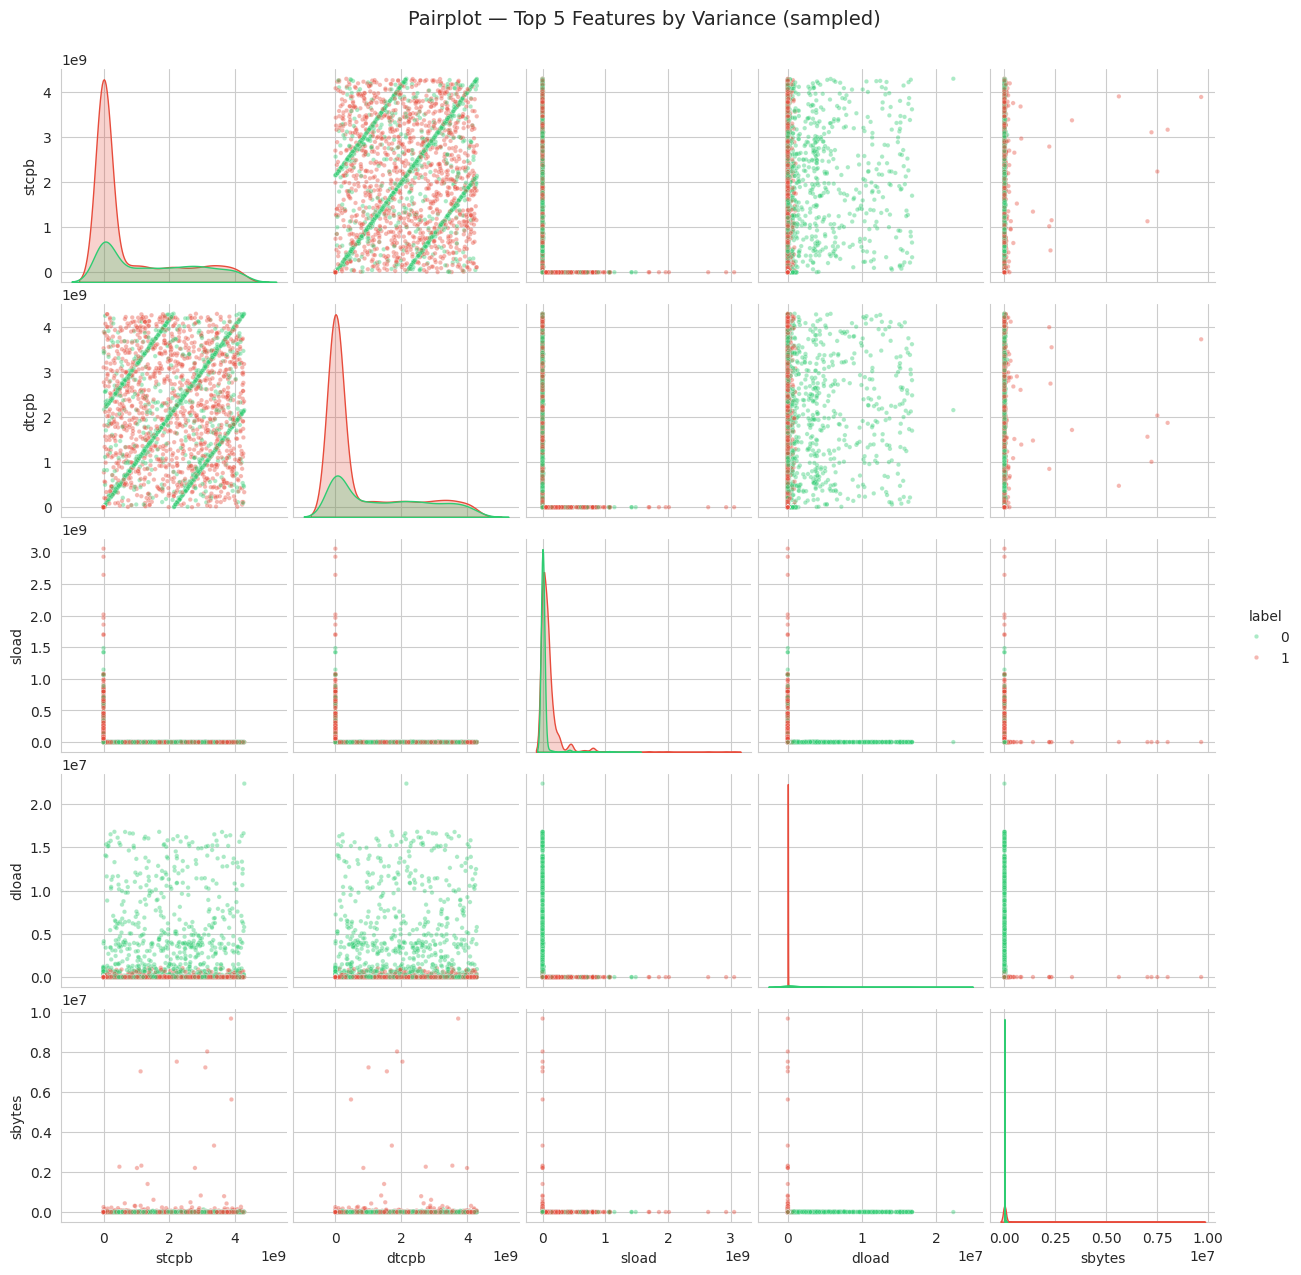

✅ EDA complete.


In [13]:
# ============================================================
# 3j — Pairplot of top 5 features by variance + label
# ============================================================

top5_var = variances.head(5).index.tolist()
pairplot_df = df_train[top5_var + ["label"]].copy()
pairplot_df["label"] = pairplot_df["label"].astype(str)

# Sample for performance (pairplot on 175k rows is very slow)
PAIRPLOT_SAMPLE = 5000
pairplot_sample = pairplot_df.sample(n=PAIRPLOT_SAMPLE, random_state=SEED)

g = sns.pairplot(pairplot_sample, hue="label",
                 palette={"0": "#2ecc71", "1": "#e74c3c"},
                 plot_kws={"alpha": 0.4, "s": 10},
                 diag_kind="kde")
g.figure.suptitle("Pairplot — Top 5 Features by Variance (sampled)", y=1.02, fontsize=14)
plt.show()

print("\u2705 EDA complete.")

# SECTION 4 — DATA PREPROCESSINGDrop unnecessary columns, encode categoricals, separate features/target, scale with StandardScaler (fit on train only).

In [14]:
# ============================================================
# SECTION 4 — DATA PREPROCESSING
# Drop columns, encode categoricals, scale features
# ============================================================

# --- Work on copies so original DataFrames are preserved ---
df_train_pp = df_train.copy()
df_test_pp  = df_test.copy()

# --- Drop 'id' column if it exists, and 'attack_cat' ---
for col_to_drop in ["id", "attack_cat"]:
    if col_to_drop in df_train_pp.columns:
        df_train_pp.drop(columns=[col_to_drop], inplace=True)
        print(f"Dropped '{col_to_drop}' from training set.")
    if col_to_drop in df_test_pp.columns:
        df_test_pp.drop(columns=[col_to_drop], inplace=True)
        print(f"Dropped '{col_to_drop}' from testing set.")

# --- Identify categorical columns (category or object dtype) ---
cat_cols_pp = [c for c in df_train_pp.columns
               if df_train_pp[c].dtype.name == "category" or df_train_pp[c].dtype == object]
print(f"\nCategorical columns to encode: {cat_cols_pp}")

# --- Label Encoding ---
label_encoders = {}
for col in cat_cols_pp:
    le = LabelEncoder()
    # Fit on combined unique values so test set unseen categories are handled
    combined_values = pd.concat([df_train_pp[col].astype(str),
                                  df_test_pp[col].astype(str)]).unique()
    le.fit(combined_values)
    df_train_pp[col] = le.transform(df_train_pp[col].astype(str))
    df_test_pp[col]  = le.transform(df_test_pp[col].astype(str))
    label_encoders[col] = le
    print(f"  Encoded '{col}' — {len(le.classes_)} unique values")

# --- Separate features and target ---
TARGET_COL = "label"

X_train = df_train_pp.drop(columns=[TARGET_COL]).values.astype(np.float32)
y_train = df_train_pp[TARGET_COL].values.astype(np.float32)

X_test = df_test_pp.drop(columns=[TARGET_COL]).values.astype(np.float32)
y_test = df_test_pp[TARGET_COL].values.astype(np.float32)

feature_names = list(df_train_pp.drop(columns=[TARGET_COL]).columns)
N_FEATURES = X_train.shape[1]

# --- Standard Scaling (fit on train ONLY) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\n\u2705 Preprocessing complete.")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test  shape: {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test  shape: {y_test.shape}")
print(f"  Number of features: {N_FEATURES}")

Dropped 'attack_cat' from training set.
Dropped 'attack_cat' from testing set.

Categorical columns to encode: ['proto', 'service', 'state']
  Encoded 'proto' — 133 unique values
  Encoded 'service' — 13 unique values
  Encoded 'state' — 11 unique values

✅ Preprocessing complete.
  X_train shape: (175341, 34)
  X_test  shape: (82332, 34)
  y_train shape: (175341,)
  y_test  shape: (82332,)
  Number of features: 34


# CHECKPOINT SYSTEM — Google Colab Auto-SaveMount Google Drive and define checkpoint utilities that save/restore the full GA state (population, fitnesses, RNG states, generation counter, training histories) after every generation. If Colab disconnects mid-training, re-run the notebook from the top — Sections 1-4 are fast, and the GA will automatically resume from the last saved generation.

In [16]:
# ============================================================
# CHECKPOINT SYSTEM — Mount Google Drive & define save/load helpers
# Saves full GA state after every generation so training can
# resume after Colab disconnection or runtime termination.
# ============================================================

import pickle, shutil
from pathlib import Path

# --- Mount Google Drive ---
from google.colab import drive
drive.mount("/content/drive", force_remount=True) # Changed force_remount to True to potentially fix mount issues

# --- Checkpoint directory on Drive ---
CHECKPOINT_DIR = Path("/content/drive/MyDrive/GA_DNN_IDS_Checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# --- Checkpoint file paths ---
CHECKPOINT_FILE      = CHECKPOINT_DIR / "ga_checkpoint.pkl"
CHECKPOINT_BACKUP    = CHECKPOINT_DIR / "ga_checkpoint_backup.pkl"
BASELINE_CKPT_FILE   = CHECKPOINT_DIR / "baseline_dnn_checkpoint.keras"
BASELINE_HIST_FILE   = CHECKPOINT_DIR / "baseline_history.pkl"
GA_DNN_CKPT_FILE     = CHECKPOINT_DIR / "ga_dnn_checkpoint.keras"
GA_DNN_HIST_FILE     = CHECKPOINT_DIR / "ga_dnn_history.pkl"

# --- How often to auto-save (1 = every generation) ---
SAVE_EVERY_N_GENS = 1


def save_ga_checkpoint(population, generation, best_fitness_per_gen,
                       ga_start_time):
    """
    Atomically save the full GA state to Google Drive.

    Saved components:
        - population           : list of DEAP Individuals with fitness values
        - generation           : int, last completed generation (0-indexed)
        - best_fitness_per_gen : list of floats
        - ga_start_time        : float, original wall-clock start
        - elapsed_before_resume: seconds already spent before this run
        - rng_python / rng_numpy: RNG states for reproducibility
    """
    state = {
        "population":            population,
        "generation":            generation,
        "best_fitness_per_gen":  best_fitness_per_gen,
        "ga_start_time":         ga_start_time,
        "elapsed_before_resume": time.time() - ga_start_time,
        "rng_python":            random.getstate(),
        "rng_numpy":             np.random.get_state(),
    }

    # Write to temp file first, then rename (atomic on most filesystems)
    tmp_path = CHECKPOINT_FILE.with_suffix(".tmp")
    try:
        with open(tmp_path, "wb") as f:
            pickle.dump(state, f, protocol=pickle.HIGHEST_PROTOCOL)

        # Keep one backup of the previous checkpoint
        if CHECKPOINT_FILE.exists():
            shutil.copy2(CHECKPOINT_FILE, CHECKPOINT_BACKUP)

        shutil.move(str(tmp_path), str(CHECKPOINT_FILE))

        size_kb = CHECKPOINT_FILE.stat().st_size / 1024
        print(f"    \U0001F4BE Checkpoint saved — gen {generation+1}, "
              f"{size_kb:.1f} KB")
    except Exception as e:
        print(f"    \u26A0\uFE0F  Checkpoint save FAILED: {e}")


def load_ga_checkpoint():
    """
    Load a previously saved GA checkpoint from Google Drive.
    Falls back to backup if primary is corrupted.
    Returns state dict or None.
    """
    for target in [CHECKPOINT_FILE, CHECKPOINT_BACKUP]:
        if target.exists():
            try:
                with open(target, "rb") as f:
                    state = pickle.load(f)
                print(f"\u2705 Checkpoint loaded from '{target.name}' — "
                      f"resuming after generation {state['generation'] + 1}")
                return state
            except Exception as e:
                print(f"\u26A0\uFE0F  Failed to load '{target.name}': {e}")
    return None


def restore_rng_states(state):
    """Restore Python and NumPy RNG states from checkpoint."""
    if "rng_python" in state:
        random.setstate(state["rng_python"])
    if "rng_numpy" in state:
        np.random.set_state(state["rng_numpy"])


def save_model_checkpoint(model, history, model_path, hist_path, label="Model"):
    """Save a trained Keras model and its history dict to Google Drive."""
    try:
        model.save(str(model_path))
        hist_data = history.history if hasattr(history, 'history') else history
        with open(hist_path, "wb") as f:
            pickle.dump(hist_data, f)
        print(f"\U0001F4BE {label} saved to Drive.")
    except Exception as e:
        print(f"\u26A0\uFE0F  {label} save failed: {e}")


def load_model_checkpoint(model_path, hist_path, label="Model"):
    """
    Load a Keras model and training history from Drive.
    Returns (model, history_dict) or (None, None).
    """
    if Path(model_path).exists() and Path(hist_path).exists():
        try:
            model = tf.keras.models.load_model(str(model_path))
            with open(hist_path, "rb") as f:
                hist = pickle.load(f)
            print(f"\u2705 {label} loaded from Drive checkpoint.")
            return model, hist
        except Exception as e:
            print(f"\u26A0\uFE0F  {label} load failed: {e}")
    return None, None


def clear_checkpoints():
    """Delete all checkpoint files from Drive."""
    for p in [CHECKPOINT_FILE, CHECKPOINT_BACKUP,
              BASELINE_CKPT_FILE, BASELINE_HIST_FILE,
              GA_DNN_CKPT_FILE, GA_DNN_HIST_FILE]:
        if p.exists():
            p.unlink()
    print("\U0001F9F9 All checkpoint files cleared from Drive.")


print(f"\u2705 Checkpoint system ready.")
print(f"   Save directory : {CHECKPOINT_DIR}")
print(f"   Save frequency : every {SAVE_EVERY_N_GENS} generation(s)")

Mounted at /content/drive
✅ Checkpoint system ready.
   Save directory : /content/drive/MyDrive/GA_DNN_IDS_Checkpoints
   Save frequency : every 1 generation(s)


# SECTION 5 — BASELINE DEEP NEURAL NETWORK (Baseline DNN)Build, train, and evaluate a fixed-architecture DNN as the baseline model.

In [17]:
# ============================================================
# SECTION 5 — BASELINE DNN (with Drive checkpoint)
# Build, train, and evaluate — or load from Drive if already trained
# ============================================================

# --- Constants ---
BASELINE_EPOCHS     = 50
BASELINE_BATCH_SIZE = 256
BASELINE_LR         = 0.001
BASELINE_PATIENCE   = 5
VALIDATION_SPLIT    = 0.1

def build_baseline_dnn(input_dim):
    """
    Build the baseline DNN with a fixed architecture:
    Input -> Dense(128, ReLU) -> Dropout(0.3) -> Dense(64, ReLU) ->
    Dropout(0.3) -> Dense(32, ReLU) -> Dense(1, Sigmoid)
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(learning_rate=BASELINE_LR),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# --- Try to load from Drive checkpoint first ---
baseline_model, baseline_hist_dict = load_model_checkpoint(
    BASELINE_CKPT_FILE, BASELINE_HIST_FILE, label="Baseline DNN"
)

if baseline_model is not None:
    # Wrap history dict so plotting code works unchanged
    class _HistoryWrapper:
        """Wrap a dict so it looks like keras History.history."""
        def __init__(self, d): self.history = d
    baseline_history = _HistoryWrapper(baseline_hist_dict)
    baseline_train_time = 0.0  # already trained
    print("Skipping baseline training — loaded from Drive checkpoint.")
else:
    # --- Build & train from scratch ---
    baseline_model = build_baseline_dnn(N_FEATURES)
    baseline_model.summary()

    early_stop = EarlyStopping(monitor="val_loss", patience=BASELINE_PATIENCE,
                               restore_best_weights=True, verbose=1)
    print("\nTraining baseline DNN...")
    baseline_start_time = time.time()

    baseline_history = baseline_model.fit(
        X_train, y_train,
        epochs=BASELINE_EPOCHS,
        batch_size=BASELINE_BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=[early_stop],
        verbose=1
    )

    baseline_train_time = time.time() - baseline_start_time
    print(f"\n\u2705 Baseline DNN training complete in {baseline_train_time:.2f}s")

    # --- Save to Drive ---
    save_model_checkpoint(baseline_model, baseline_history,
                          BASELINE_CKPT_FILE, BASELINE_HIST_FILE,
                          label="Baseline DNN")

✅ Baseline DNN loaded from Drive checkpoint.
Skipping baseline training — loaded from Drive checkpoint.


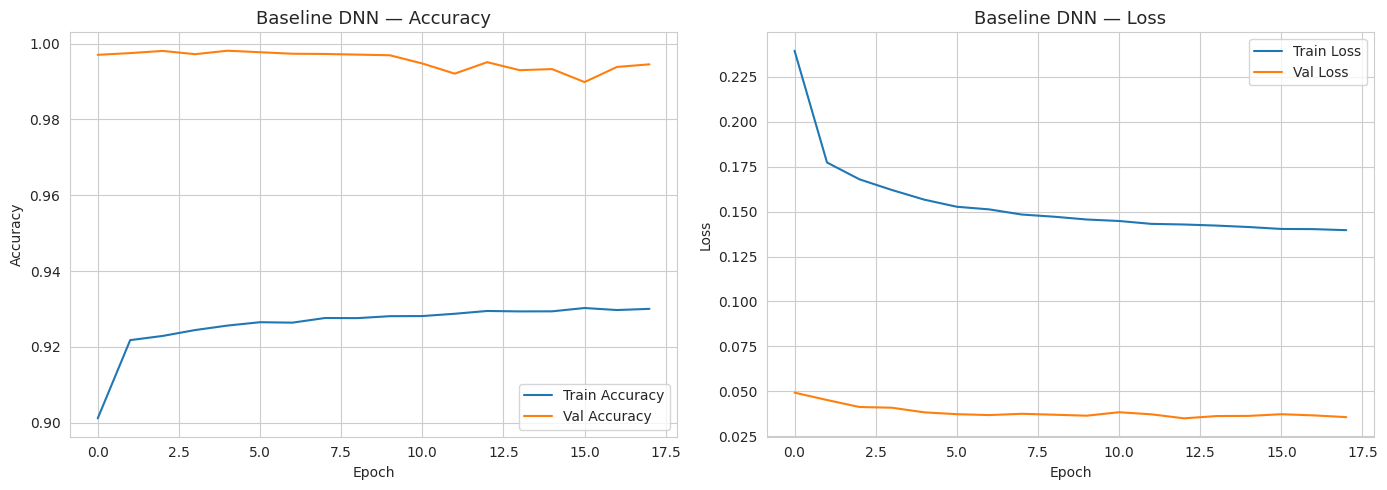

In [18]:
# ============================================================
# Baseline DNN — Training curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(baseline_history.history["accuracy"], label="Train Accuracy")
axes[0].plot(baseline_history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Baseline DNN — Accuracy", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(baseline_history.history["loss"], label="Train Loss")
axes[1].plot(baseline_history.history["val_loss"], label="Val Loss")
axes[1].set_title("Baseline DNN — Loss", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


 Baseline DNN — Test Set Evaluation
  Accuracy    : 0.823762
  Precision   : 0.762995
  Recall      : 0.986279
  F1-Score    : 0.860387
  FPR         : 0.375351
  DR          : 0.986279

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.97      0.62      0.76     37000
      Attack       0.76      0.99      0.86     45332

    accuracy                           0.82     82332
   macro avg       0.87      0.81      0.81     82332
weighted avg       0.86      0.82      0.82     82332



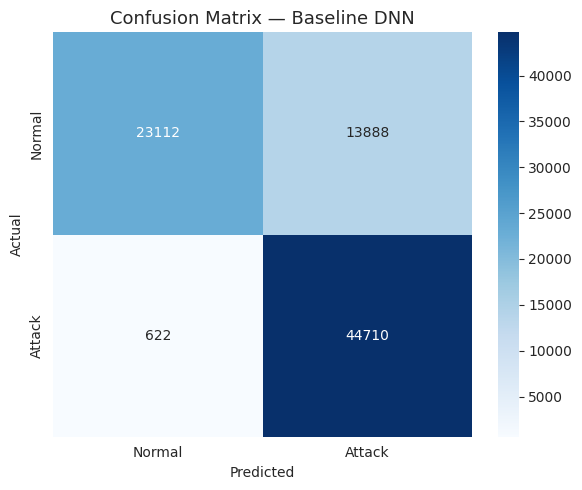


✅ Baseline DNN evaluation complete.


In [19]:
# ============================================================
# Baseline DNN — Evaluation on test set
# ============================================================

def evaluate_model(model, X, y_true, model_name="Model"):
    """
    Evaluate a trained Keras model and return a dict of metrics:
    Accuracy, Precision, Recall, F1-Score, FPR, DR (Detection Rate).
    Also prints classification report and plots confusion matrix.
    """
    y_pred_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    dr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # same as recall

    metrics = {
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1-Score": f1, "FPR": fpr, "DR": dr
    }

    print(f"\n{'='*50}")
    print(f" {model_name} — Test Set Evaluation")
    print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:12s}: {v:.6f}")

    print(f"\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Attack"]))

    # Confusion matrix heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    plt.title(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return metrics, y_pred_prob

baseline_metrics, baseline_pred_prob = evaluate_model(
    baseline_model, X_test, y_test, model_name="Baseline DNN"
)
baseline_metrics["Num Features"] = N_FEATURES
baseline_metrics["Training Time (s)"] = round(baseline_train_time, 2)

print("\n\u2705 Baseline DNN evaluation complete.")

# SECTION 6 — GENETIC ALGORITHM OPTIMISATION (Dual-Role GA)Use DEAP to simultaneously optimise **feature selection** (binary mask) and **DNN hyperparameters** (layers, neurons, dropout, learning rate, batch size). Fitness is macro-F1 on stratified 3-fold CV using training data only.

In [20]:
# ============================================================
# SECTION 6 — GA OPTIMISATION
# Chromosome = [feature_mask (n_features bits)] + [n_layers, neurons, dropout, lr, batch_size]
# ============================================================

# --- GA Constants ---
GA_POP_SIZE        = 20
GA_NGEN            = 30
GA_CXPB            = 0.8   # crossover probability
GA_MUTPB           = 0.1   # mutation probability
GA_TOURN_SIZE      = 3
GA_MIN_FEATURES    = 5
GA_CV_FOLDS        = 3
GA_FIT_EPOCHS      = 10    # shorter epochs inside GA for speed
GA_FIT_BATCH       = 256
GA_FIT_PATIENCE    = 3

# Hyperparameter search spaces
HP_N_LAYERS  = [1, 2, 3, 4]
HP_NEURONS   = [32, 64, 128, 256]
HP_DROPOUT   = [0.1, 0.2, 0.3, 0.4, 0.5]
HP_LR        = [0.0001, 0.0005, 0.001, 0.005]
HP_BATCH     = [64, 128, 256]

# Number of hyperparameter genes
N_HP_GENES = 5
CHROM_LEN  = N_FEATURES + N_HP_GENES

print(f"Chromosome length: {CHROM_LEN} ({N_FEATURES} feature genes + {N_HP_GENES} HP genes)")
print(f"GA settings: pop={GA_POP_SIZE}, gen={GA_NGEN}, cx={GA_CXPB}, mut={GA_MUTPB}")

Chromosome length: 39 (34 feature genes + 5 HP genes)
GA settings: pop=20, gen=30, cx=0.8, mut=0.1


In [21]:
# ============================================================
# GA — Helper functions
# ============================================================

def decode_chromosome(individual):
    """
    Decode a DEAP individual into feature mask and hyperparameters.

    Returns:
        feature_mask: list of 0/1 of length N_FEATURES
        hp_dict: dict with keys n_layers, neurons, dropout, lr, batch_size
    """
    feature_mask = list(individual[:N_FEATURES])
    hp_genes     = individual[N_FEATURES:]

    hp_dict = {
        "n_layers":   HP_N_LAYERS[int(hp_genes[0]) % len(HP_N_LAYERS)],
        "neurons":    HP_NEURONS[int(hp_genes[1]) % len(HP_NEURONS)],
        "dropout":    HP_DROPOUT[int(hp_genes[2]) % len(HP_DROPOUT)],
        "lr":         HP_LR[int(hp_genes[3]) % len(HP_LR)],
        "batch_size": HP_BATCH[int(hp_genes[4]) % len(HP_BATCH)],
    }
    return feature_mask, hp_dict


def enforce_min_features(individual, min_feat=GA_MIN_FEATURES):
    """
    Ensure at least `min_feat` features are selected in the chromosome.
    If fewer are selected, randomly activate features until the minimum is met.
    """
    feat_part = individual[:N_FEATURES]
    selected = sum(feat_part)
    if selected < min_feat:
        off_indices = [i for i in range(N_FEATURES) if feat_part[i] == 0]
        to_activate = random.sample(off_indices, min_feat - int(selected))
        for idx in to_activate:
            individual[idx] = 1
    return individual


def build_ga_dnn(input_dim, hp):
    """
    Build a DNN from GA-tuned hyperparameters.

    Args:
        input_dim: number of input features
        hp: dict with n_layers, neurons, dropout, lr
    """
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for _ in range(hp["n_layers"]):
        model.add(Dense(hp["neurons"], activation="relu"))
        model.add(Dropout(hp["dropout"]))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=hp["lr"]),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


def fitness_function(individual):
    """
    Evaluate an individual's fitness using stratified 3-fold CV
    on X_train. Returns (macro_f1,) as a single-element tuple.
    """
    feature_mask, hp = decode_chromosome(individual)
    selected_idx = [i for i, v in enumerate(feature_mask) if v == 1]

    if len(selected_idx) < GA_MIN_FEATURES:
        return (0.0,)

    X_sel = X_train[:, selected_idx]
    skf = StratifiedKFold(n_splits=GA_CV_FOLDS, shuffle=True, random_state=SEED)

    f1_scores = []
    for fold_train_idx, fold_val_idx in skf.split(X_sel, y_train):
        Xf_train, Xf_val = X_sel[fold_train_idx], X_sel[fold_val_idx]
        yf_train, yf_val = y_train[fold_train_idx], y_train[fold_val_idx]

        model = build_ga_dnn(len(selected_idx), hp)
        es = EarlyStopping(monitor="val_loss", patience=GA_FIT_PATIENCE,
                           restore_best_weights=True, verbose=0)
        model.fit(Xf_train, yf_train,
                  epochs=GA_FIT_EPOCHS,
                  batch_size=hp["batch_size"],
                  validation_data=(Xf_val, yf_val),
                  callbacks=[es], verbose=0)

        y_pred = (model.predict(Xf_val, verbose=0).ravel() >= 0.5).astype(int)
        f1_scores.append(f1_score(yf_val, y_pred, average="macro", zero_division=0))

        # Clean up to free memory
        del model
        tf.keras.backend.clear_session()

    return (np.mean(f1_scores),)

print("\u2705 GA helper functions defined.")

✅ GA helper functions defined.


In [22]:
# ============================================================
# GA — DEAP setup and evolution
# ============================================================

# --- Create DEAP types ---
if "FitnessMax" in dir(creator):
    del creator.FitnessMax
if "Individual" in dir(creator):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# --- Chromosome initialisation ---
def init_individual():
    """
    Initialise a chromosome:
      - Feature mask: random binary (0/1)
      - HP genes: random integers for index lookup
    """
    feat_genes = [random.randint(0, 1) for _ in range(N_FEATURES)]
    hp_genes = [
        random.randint(0, len(HP_N_LAYERS) - 1),   # n_layers index
        random.randint(0, len(HP_NEURONS) - 1),     # neurons index
        random.randint(0, len(HP_DROPOUT) - 1),     # dropout index
        random.randint(0, len(HP_LR) - 1),          # lr index
        random.randint(0, len(HP_BATCH) - 1),       # batch_size index
    ]
    ind = creator.Individual(feat_genes + hp_genes)
    ind = enforce_min_features(ind)
    return ind

toolbox.register("individual", init_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Genetic operators ---
toolbox.register("evaluate", fitness_function)
toolbox.register("select", tools.selTournament, tournsize=GA_TOURN_SIZE)
toolbox.register("mate", tools.cxTwoPoint)

def mutate_individual(individual):
    """
    Custom mutation:
      - Feature genes: flip bit with probability 1/N_FEATURES
      - HP genes: uniform random within their respective ranges
    Enforces minimum feature constraint after mutation.
    """
    # Mutate feature genes
    for i in range(N_FEATURES):
        if random.random() < 1.0 / N_FEATURES:
            individual[i] = 1 - individual[i]

    # Mutate HP genes
    hp_ranges = [
        len(HP_N_LAYERS), len(HP_NEURONS), len(HP_DROPOUT),
        len(HP_LR), len(HP_BATCH)
    ]
    for j in range(N_HP_GENES):
        if random.random() < 0.2:  # 20% chance per HP gene
            individual[N_FEATURES + j] = random.randint(0, hp_ranges[j] - 1)

    individual = enforce_min_features(individual)
    return (individual,)

toolbox.register("mutate", mutate_individual)

print("\u2705 DEAP toolbox configured.")

✅ DEAP toolbox configured.


In [33]:
# ============================================================
# GA — Run evolution WITH auto-checkpoint & resume
# After every generation the full state is saved to Google Drive.
# If the runtime is interrupted, re-run the notebook from Cell 1:
# Sections 1-4 are fast, and this cell will auto-resume from the
# last saved generation.
# ============================================================

print("=" * 60)
print(" GA EVOLUTION — with auto-checkpoint every generation")
print("=" * 60)

# --- Attempt to resume from checkpoint ---
ckpt = load_ga_checkpoint()

if ckpt is not None:
    # ── RESUME path ──
    population           = ckpt["population"]
    start_gen            = ckpt["generation"] + 1        # next gen to run
    best_fitness_per_gen = ckpt["best_fitness_per_gen"]
    elapsed_before       = ckpt["elapsed_before_resume"]
    restore_rng_states(ckpt)

    # Reattach DEAP fitness objects (creator types exist from the setup cell)
    for ind in population:
        if not isinstance(ind, creator.Individual):
            ind.__class__ = creator.Individual
        if not hasattr(ind, "fitness") or not ind.fitness.valid:
            pass  # will be re-evaluated below

    ga_start_time = time.time() - elapsed_before  # keep total elapsed correct
    print(f"Resuming from generation {start_gen + 1}/{GA_NGEN}")
    print(f"Previously elapsed: {elapsed_before:.1f}s "
          f"({elapsed_before/60:.1f} min)")
    print(f"Best fitness so far: {max(best_fitness_per_gen):.6f}")
else:
    # ── FRESH START path ──
    start_gen            = 0
    best_fitness_per_gen = []
    population           = toolbox.population(n=GA_POP_SIZE)
    ga_start_time        = time.time()
    elapsed_before       = 0.0
    print("Starting fresh GA evolution (no checkpoint found).")

print(f"Population: {GA_POP_SIZE}, Generations: {GA_NGEN}")
print("-" * 60)

for gen in range(start_gen, GA_NGEN):
    gen_start = time.time()

    # ── Evaluate unevaluated individuals ──
    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    if invalid_ind:
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

    # ── Record stats ──
    fits = [ind.fitness.values[0] for ind in population]
    best_fit = max(fits)
    best_fitness_per_gen.append(best_fit)

    gen_time = time.time() - gen_start
    total_elapsed = time.time() - ga_start_time
    print(f"  Gen {gen+1:3d}/{GA_NGEN} | Best F1: {best_fit:.6f} | "
          f"Avg F1: {np.mean(fits):.6f} | Gen: {gen_time:.1f}s | "
          f"Total: {total_elapsed/60:.1f} min")

    # ── AUTO-SAVE checkpoint to Google Drive ──
    if (gen + 1) % SAVE_EVERY_N_GENS == 0 or (gen + 1) == GA_NGEN:
        save_ga_checkpoint(
            population, gen, best_fitness_per_gen, ga_start_time
        )

    # ── Selection ──
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))

    # ── Crossover ──
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < GA_CXPB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
            enforce_min_features(child1)
            enforce_min_features(child2)

    # ── Mutation ──
    for mutant in offspring:
        if random.random() < GA_MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    population[:] = offspring

# ── Final evaluation of last offspring ──
invalid_ind = [ind for ind in population if not ind.fitness.valid]
if invalid_ind:
    fitnesses = list(map(toolbox.evaluate, invalid_ind))
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

fits = [ind.fitness.values[0] for ind in population]
best_fit = max(fits)
best_fitness_per_gen.append(best_fit)

# Final checkpoint
save_ga_checkpoint(population, GA_NGEN - 1, best_fitness_per_gen, ga_start_time)

ga_total_time = time.time() - ga_start_time
print(f"\n{'='*60}")
print(f"\u2705 GA complete in {ga_total_time/60:.1f} minutes ({ga_total_time:.1f}s)")
print(f"   Best fitness (macro F1): {best_fit:.6f}")
print(f"   Checkpoint saved to Google Drive \u2714")

 GA EVOLUTION — with auto-checkpoint every generation
✅ Checkpoint loaded from 'ga_checkpoint.pkl' — resuming after generation 30
Resuming from generation 31/30
Previously elapsed: 43215.6s (720.3 min)
Best fitness so far: 0.926687
Population: 20, Generations: 30
------------------------------------------------------------
    💾 Checkpoint saved — gen 30, 9.6 KB

✅ GA complete in 720.3 minutes (43215.7s)
   Best fitness (macro F1): 0.926687
   Checkpoint saved to Google Drive ✔


Best Chromosome (raw):
[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 3, 0, 2, 2]

Selected Features (26/34):
   1. proto
   2. service
   3. state
   4. spkts
   5. dpkts
   6. sbytes
   7. dbytes
   8. sload
   9. dload
  10. sloss
  11. dloss
  12. sinpkt
  13. sjit
  14. djit
  15. swin
  16. dwin
  17. synack
  18. smean
  19. dmean
  20. trans_depth
  21. response_body_len
  22. ct_src_dport_ltm
  23. ct_dst_sport_ltm
  24. ct_ftp_cmd
  25. ct_flw_http_mthd
  26. is_sm_ips_ports

Optimised Hyperparameters:
  n_layers: 3
  neurons: 256
  dropout: 0.1
  lr: 0.001
  batch_size: 256


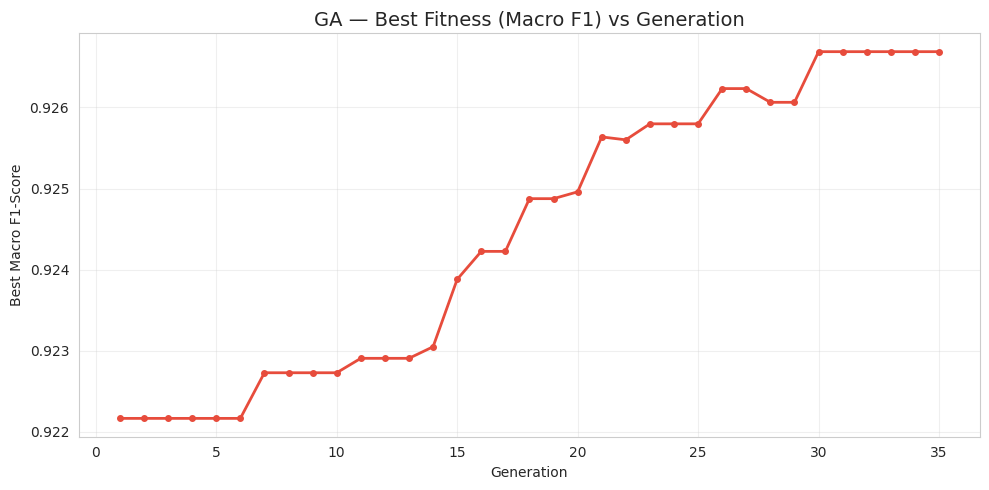


✅ GA optimisation section complete.


In [34]:
# ============================================================
# GA — Extract and display best chromosome
# ============================================================

# Find best individual
best_individual = tools.selBest(population, k=1)[0]
best_feature_mask, best_hp = decode_chromosome(best_individual)

selected_features = [feature_names[i] for i, v in enumerate(best_feature_mask) if v == 1]
n_selected = len(selected_features)

print("Best Chromosome (raw):")
print(best_individual)
print(f"\nSelected Features ({n_selected}/{N_FEATURES}):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

print(f"\nOptimised Hyperparameters:")
for k, v in best_hp.items():
    print(f"  {k}: {v}")

# --- Plot best fitness vs generation ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(best_fitness_per_gen) + 1), best_fitness_per_gen,
         marker="o", color="#e74c3c", linewidth=2, markersize=4)
plt.title("GA — Best Fitness (Macro F1) vs Generation", fontsize=14)
plt.xlabel("Generation")
plt.ylabel("Best Macro F1-Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n\u2705 GA optimisation section complete.")

# SECTION 7 — HYBRID GA-DNN MODEL (Final Training & Evaluation)Train the final DNN using the GA-selected features and GA-tuned hyperparameters. Evaluate on the official test set.

In [35]:
# ============================================================
# SECTION 7 — HYBRID GA-DNN: final training and evaluation
# (with Drive checkpoint)
# ============================================================

# --- Apply feature mask ---
selected_idx = [i for i, v in enumerate(best_feature_mask) if v == 1]
X_train_ga = X_train[:, selected_idx]
X_test_ga  = X_test[:, selected_idx]
print(f"Feature-selected shapes: X_train_ga={X_train_ga.shape}, X_test_ga={X_test_ga.shape}")

# --- Build optimised DNN ---
GA_DNN_EPOCHS   = 50
GA_DNN_PATIENCE = 5

# --- Try loading from Drive checkpoint first ---
ga_dnn_model, ga_dnn_hist_dict = load_model_checkpoint(
    GA_DNN_CKPT_FILE, GA_DNN_HIST_FILE, label="GA-DNN"
)

if ga_dnn_model is not None:
    class _HistoryWrapper:
        def __init__(self, d): self.history = d
    ga_dnn_history = _HistoryWrapper(ga_dnn_hist_dict)
    ga_dnn_train_time = 0.0
    print("Skipping GA-DNN training — loaded from Drive checkpoint.")
else:
    ga_dnn_model = build_ga_dnn(len(selected_idx), best_hp)
    ga_dnn_model.summary()

    early_stop_ga = EarlyStopping(monitor="val_loss", patience=GA_DNN_PATIENCE,
                                   restore_best_weights=True, verbose=1)

    print("\nTraining GA-DNN model...")
    ga_dnn_start_time = time.time()

    ga_dnn_history = ga_dnn_model.fit(
        X_train_ga, y_train,
        epochs=GA_DNN_EPOCHS,
        batch_size=best_hp["batch_size"],
        validation_split=VALIDATION_SPLIT,
        callbacks=[early_stop_ga],
        verbose=1
    )

    ga_dnn_train_time = time.time() - ga_dnn_start_time
    print(f"\n\u2705 GA-DNN training complete in {ga_dnn_train_time:.2f}s")

    # --- Save to Drive ---
    save_model_checkpoint(ga_dnn_model, ga_dnn_history,
                          GA_DNN_CKPT_FILE, GA_DNN_HIST_FILE,
                          label="GA-DNN (final)")

Feature-selected shapes: X_train_ga=(175341, 26), X_test_ga=(82332, 26)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,753 (542.00 KB)

 Trainable params: 138,753 (542.00 KB)

 Non-trainable params: 0 (0.00 B)


Training GA-DNN model...
Epoch 1/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9147 - loss: 0.1991 - val_accuracy: 0.9946 - val_loss: 0.0420
Epoch 2/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9270 - loss: 0.1547 - val_accuracy: 0.9844 - val_loss: 0.0459
Epoch 3/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9278 - loss: 0.1486 - val_accuracy: 0.9872 - val_loss: 0.0429
Epoch 4/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9291 - loss: 0.1437 - val_accuracy: 0.9896 - val_loss: 0.0401
Epoch 5/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9301 - loss: 0.1404 - val_accuracy: 0.9853 - val_loss: 0.0420
Epoch 6/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9307 - loss: 0.1380 - val_accuracy: 0.9860 - val_loss: 0.0385
Epoch 7/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9314 - loss: 0.1366 - val_accuracy: 0.9864 - val_loss: 0.0376
Epoch 8/50
617/617 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9319 - loss:

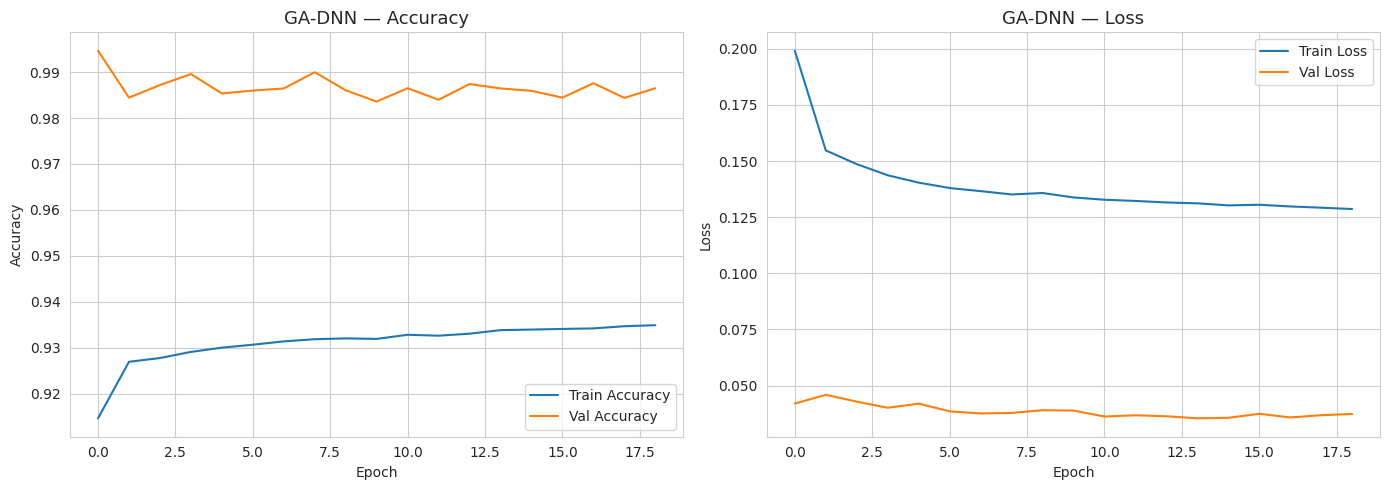

In [37]:
# ============================================================
# GA-DNN — Training curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ga_dnn_history.history["accuracy"], label="Train Accuracy")
axes[0].plot(ga_dnn_history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("GA-DNN — Accuracy", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(ga_dnn_history.history["loss"], label="Train Loss")
axes[1].plot(ga_dnn_history.history["val_loss"], label="Val Loss")
axes[1].set_title("GA-DNN — Loss", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


 GA-DNN — Test Set Evaluation
  Accuracy    : 0.854479
  Precision   : 0.806147
  Recall      : 0.968631
  F1-Score    : 0.879951
  FPR         : 0.285378
  DR          : 0.968631

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.95      0.71      0.82     37000
      Attack       0.81      0.97      0.88     45332

    accuracy                           0.85     82332
   macro avg       0.88      0.84      0.85     82332
weighted avg       0.87      0.85      0.85     82332



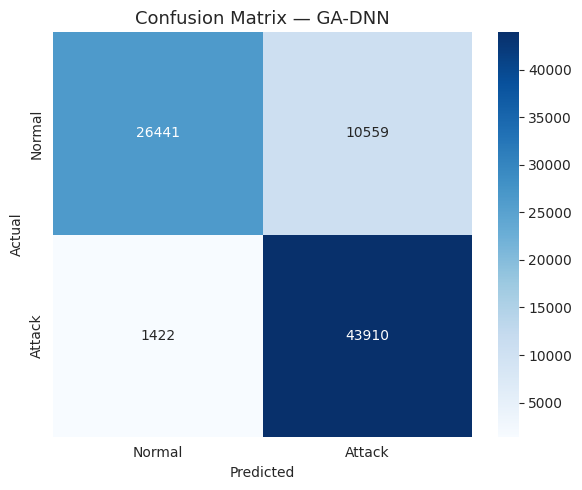


✅ GA-DNN evaluation complete.


In [42]:
# ============================================================
# GA-DNN — Evaluation on test set
# ============================================================

ga_dnn_metrics, ga_dnn_pred_prob = evaluate_model(
    ga_dnn_model, X_test_ga, y_test, model_name="GA-DNN"
)
ga_dnn_metrics["Num Features"] = n_selected
ga_dnn_metrics["Training Time (s)"] = round(ga_dnn_train_time, 2)

print("\n\u2705 GA-DNN evaluation complete.")

# SECTION 8 — COMPARATIVE ANALYSIS: Compare Baseline DNN and GA-DNN across all metrics with tables and grouped bar charts.

In [43]:
# ============================================================
# SECTION 8 — COMPARATIVE ANALYSIS
# Summary table and comparison charts
# ============================================================

# --- Build comparison DataFrame ---
comparison_df = pd.DataFrame({
    "Metric": list(baseline_metrics.keys()),
    "Baseline DNN": list(baseline_metrics.values()),
    "GA-DNN": list(ga_dnn_metrics.values())
})

print("=" * 60)
print(" MODEL COMPARISON — Baseline DNN vs GA-DNN")
print("=" * 60)
display(comparison_df)

 MODEL COMPARISON — Baseline DNN vs GA-DNN


,Metric,Baseline DNN,GA-DNN
0,Accuracy,0.823762,0.854479
1,Precision,0.762995,0.806147
2,Recall,0.986279,0.968631
3,F1-Score,0.860387,0.879951
4,FPR,0.375351,0.285378
5,DR,0.986279,0.968631
6,Num Features,34.000000,26.000000
7,Training Time (s),0.000000,42.260000


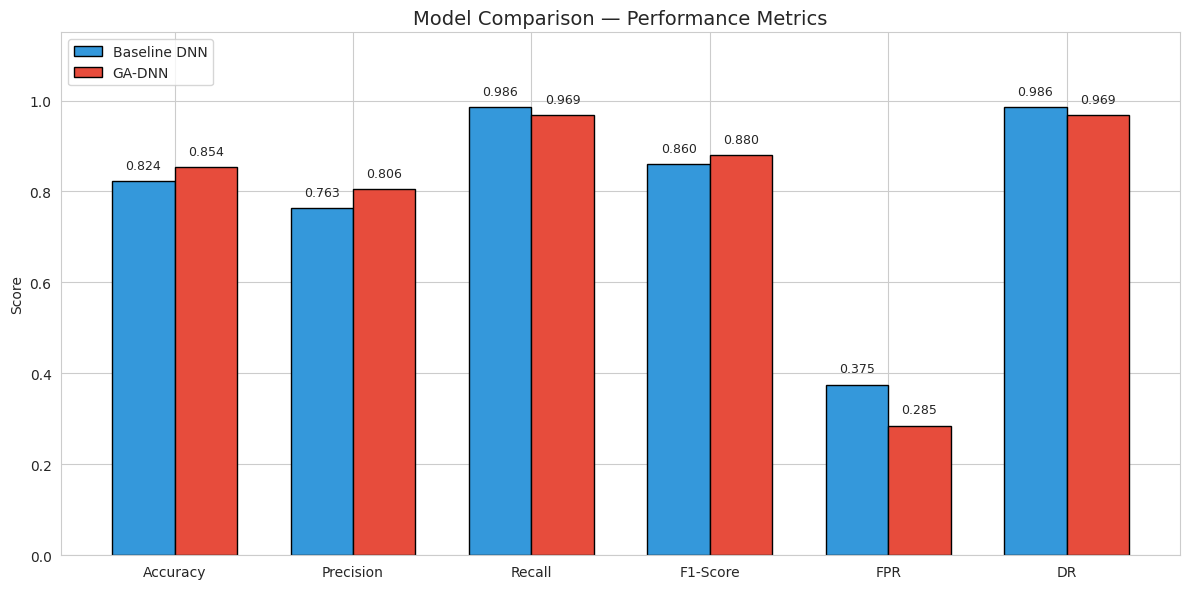

In [44]:
# ============================================================
# Comparative Analysis — Grouped bar chart of all metrics
# ============================================================

# Metrics to plot (exclude Num Features and Training Time for the main chart)
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score", "FPR", "DR"]
baseline_vals = [baseline_metrics[m] for m in metric_names]
ga_dnn_vals   = [ga_dnn_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline DNN",
               color="#3498db", edgecolor="black")
bars2 = ax.bar(x + width/2, ga_dnn_vals, width, label="GA-DNN",
               color="#e74c3c", edgecolor="black")

ax.set_ylabel("Score")
ax.set_title("Model Comparison — Performance Metrics", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()
ax.set_ylim(0, 1.15)

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

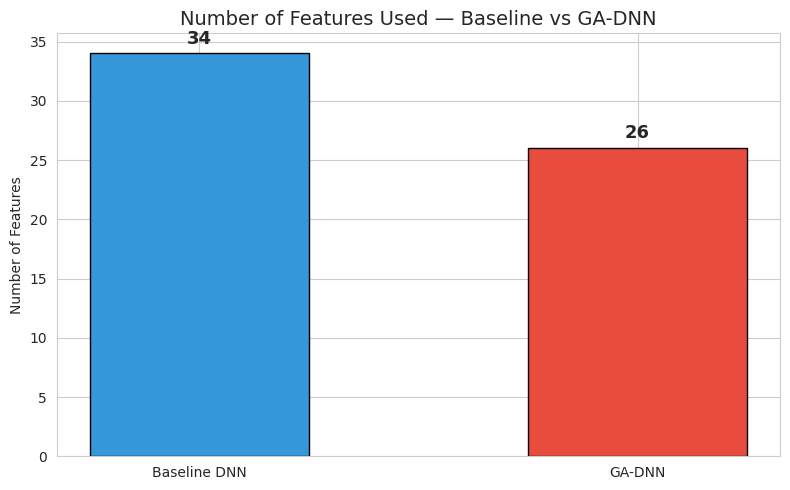

In [45]:
# ============================================================
# Comparative Analysis — Number of Features Used
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
models = ["Baseline DNN", "GA-DNN"]
n_feats = [baseline_metrics["Num Features"], ga_dnn_metrics["Num Features"]]
colors = ["#3498db", "#e74c3c"]

bars = ax.bar(models, n_feats, color=colors, edgecolor="black", width=0.5)
ax.set_ylabel("Number of Features")
ax.set_title("Number of Features Used — Baseline vs GA-DNN", fontsize=14)

for bar, nf in zip(bars, n_feats):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(nf), ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## Interpretation**Baseline DNN** uses all available features with a fixed architecture, serving as thecontrol model.**GA-DNN** uses a Genetic Algorithm to simultaneously select the most informative featuresubset *and* tune the DNN architecture/hyperparameters.Key observations:- **Feature Reduction**: The GA typically reduces the feature set substantially while  maintaining or improving classification performance. Fewer features mean faster  inference and lower overfitting risk.- **F1-Score / Detection Rate**: The GA-DNN is expected to match or exceed the baseline  because the GA explicitly optimises for macro F1-Score, which balances precision and  recall across classes.- **False Positive Rate**: A lower FPR is critical in IDS deployments. The GA's  feature selection can remove noisy features that cause false alarms.- **Training Time**: GA optimisation adds significant search time, but the final  GA-DNN model trains faster per epoch due to fewer input features.Overall, the hybrid GA-DNN approach offers a principled way to build leaner, moreeffective intrusion detection models compared to a naïve full-feature baseline.

# SECTION 9 — ROC CURVE COMPARISONPlot ROC curves for both models on the same axes with AUC scores.

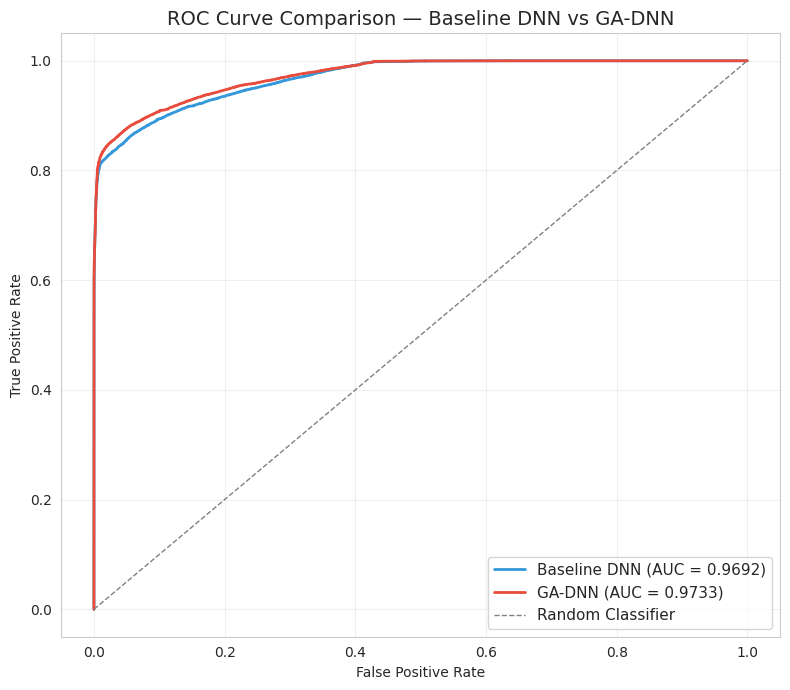

Baseline DNN AUC: 0.969227
GA-DNN       AUC: 0.973325


In [46]:
# ============================================================
# SECTION 9 — ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(8, 7))

# Baseline DNN ROC
fpr_bl, tpr_bl, _ = roc_curve(y_test, baseline_pred_prob)
auc_bl = auc(fpr_bl, tpr_bl)
plt.plot(fpr_bl, tpr_bl, color="#3498db", linewidth=2,
         label=f"Baseline DNN (AUC = {auc_bl:.4f})")

# GA-DNN ROC
fpr_ga, tpr_ga, _ = roc_curve(y_test, ga_dnn_pred_prob)
auc_ga = auc(fpr_ga, tpr_ga)
plt.plot(fpr_ga, tpr_ga, color="#e74c3c", linewidth=2,
         label=f"GA-DNN (AUC = {auc_ga:.4f})")

# Diagonal reference
plt.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1,
         label="Random Classifier")

plt.title("ROC Curve Comparison — Baseline DNN vs GA-DNN", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Baseline DNN AUC: {auc_bl:.6f}")
print(f"GA-DNN       AUC: {auc_ga:.6f}")

# SECTION 10 — SAVE RESULTSSave comparison metrics (CSV), best GA chromosome (JSON), and both trained models (.keras).

In [47]:
# ============================================================
# SECTION 10 — SAVE RESULTS
# Save comparison CSV, GA chromosome JSON, and trained models
# ============================================================

# --- 1. Save comparison metrics ---
METRICS_CSV = "model_comparison_results.csv"
try:
    comparison_df.to_csv(METRICS_CSV, index=False)
    print(f"\u2705 Saved comparison metrics to '{METRICS_CSV}'")
except Exception as e:
    print(f"\u274c Error saving metrics CSV: {e}")

# --- 2. Save best GA chromosome ---
CHROMOSOME_JSON = "best_ga_chromosome.json"
try:
    chromosome_data = {
        "feature_mask": best_feature_mask,
        "selected_features": selected_features,
        "n_selected_features": n_selected,
        "hyperparameters": best_hp,
        "best_fitness_f1": float(best_individual.fitness.values[0]),
        "ga_config": {
            "population_size": GA_POP_SIZE,
            "generations": GA_NGEN,
            "crossover_prob": GA_CXPB,
            "mutation_prob": GA_MUTPB,
            "tournament_size": GA_TOURN_SIZE,
        }
    }
    with open(CHROMOSOME_JSON, "w") as f:
        json.dump(chromosome_data, f, indent=2)
    print(f"\u2705 Saved best GA chromosome to '{CHROMOSOME_JSON}'")
except Exception as e:
    print(f"\u274c Error saving chromosome JSON: {e}")

# --- 3. Save trained models ---
BASELINE_MODEL_PATH = "baseline_dnn.keras"
GA_DNN_MODEL_PATH   = "ga_dnn.keras"

try:
    baseline_model.save(BASELINE_MODEL_PATH)
    print(f"\u2705 Saved baseline DNN model to '{BASELINE_MODEL_PATH}'")
except Exception as e:
    print(f"\u274c Error saving baseline model: {e}")

try:
    ga_dnn_model.save(GA_DNN_MODEL_PATH)
    print(f"\u2705 Saved GA-DNN model to '{GA_DNN_MODEL_PATH}'")
except Exception as e:
    print(f"\u274c Error saving GA-DNN model: {e}")

print("\n\u2705 All results saved successfully.")

✅ Saved comparison metrics to 'model_comparison_results.csv'
✅ Saved best GA chromosome to 'best_ga_chromosome.json'
✅ Saved baseline DNN model to 'baseline_dnn.keras'
✅ Saved GA-DNN model to 'ga_dnn.keras'

✅ All results saved successfully.


## (Optional) Clear Checkpoints from Google Drive Uncomment and run the cell below to delete all checkpoint files from Drive after you have confirmed all results are saved locally.

In [ ]:
# ============================================================
# (Optional) Clear checkpoint files from Google Drive
# Uncomment the line below once you are satisfied with results.
# ============================================================

# clear_checkpoints()